# Acoustic Mode Synthesis - Predicted Impact Signature

Author: Stellars Henson<br>
Approach: full Kirchhoff plate-mode catalogue for the elevator door (steel panel +
glass window) plus the cavity axial mode, synthesised into an audio signal that
approximates what a phone microphone would have recorded at the moment of the
contested back-first impact.  Envelopes are gamma-shaped per mode with sharp
attack and exponential decay; output is peak-normalised to -1 dBFS with no
clipping.

## Approach

1. **Mode catalogue** - enumerate all (m, n) plate flexural modes for the door
   panel and glass window via Kirchhoff thin-plate theory, and the first axial
   cavity mode from the 3 cm air gap.  No truncation to "first 6" - everything
   the physics predicts goes into the synthesis.
2. **Envelope design** - per-mode gamma envelope `A(t) = (t/tau)^(k-1) * exp(-t/tau)`
   with `k = 1.5` (sharp attack), tau scaling inversely with frequency so high
   modes decay faster than low modes - matches structural damping in steel and
   glass.
3. **Synthesis** - sum all modes with random phases, add a short broadband contact
   burst for the mechanical strike itself, peak-normalise to -1 dBFS (0.89).
4. **Validation** - FFT and spectrogram to confirm the synthesised spectrum
   matches the predicted mode catalogue.
5. **Export** - WAV (lossless) + MP3 (libmp3lame, V2 VBR) under
   `reports/figures/` for inclusion in the analysis pipeline.

## Outputs

- `reports/figures/02-mode-catalogue.png` - bar chart of all panel + window mode frequencies
- `reports/figures/02-envelope-shapes.png` - gamma envelopes per mode family
- `reports/figures/02-strike-waveform.png` - time-domain rendered signal
- `reports/figures/02-strike-spectrogram.png` - time-frequency analysis
- `reports/figures/02-predicted-impact-audio.wav` - synthesized impact signature
- `reports/figures/02-predicted-impact-audio.mp3` - same, MP3 V2

In [1]:
# Imports
from __future__ import annotations

from pathlib import Path
import subprocess

# Numerical / data
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Rich console
from rich.console import Console
from rich.panel import Panel
from rich.table import Table

# Audio I/O
from scipy.io import wavfile
from scipy.signal import spectrogram
import imageio_ffmpeg

# Inline playback in the notebook
from IPython.display import Audio, display

# Project library
from henryk_simulations.corridor.acoustics import (
    DEFAULT_ELEVATOR_DOOR,
    cavity_axial_frequency,
    plate_modes,
)

# Autoreload while iterating on the library
%load_ext autoreload
%autoreload 2

console = Console()
sns.set_theme(style="whitegrid", context="notebook")

2026-05-15 14:49:29.228 | INFO     | henryk_simulations.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/private/henryk/henryk-simulations


In [2]:
# Reproducibility - the broadband contact burst and per-mode initial phases are stochastic
SEED = 42
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

## Configuration

Single source of truth for every numeric knob in this notebook. Sharper envelope =
smaller `tau`; higher amplitude = larger `STRIKE_GAIN_2X` (kept at 2.0 as
requested).  Peak is normalised after summing so no clipping ever occurs.

In [3]:
PARAMS = {
    "audio": {
        "sample_rate_hz": 44100,
        "duration_s": 2.0,
        "lead_silence_s": 0.20,      # ambient context before the strike
        "peak_dbfs": -1.0,            # final peak target after normalisation
        "ambient_dbfs": -55.0,        # mic self-noise / hallway ambient floor
    },
    "modes": {
        "n_max": 8,                   # plate modes per dimension -> 64 per surface
        "include_panel": True,
        "include_window": True,
        "include_cavity": True,
    },
    "envelope": {
        # Gamma envelope: A(t) = (t/tau)^(k-1) * exp(-t/tau).
        # Smaller k -> sharper attack.  k=1 is pure exp; k=1.5 has tiny rise.
        "k_shape": 1.5,
        # Per-family time constants (s).  Smaller = sharper, faster decay.
        "tau_panel_s": 0.12,          # steel plate - was 0.22 in v1
        "tau_window_s": 0.09,          # glass window - was 0.18 in v1
        "tau_cavity_s": 0.020,         # trapped-air cavity - was 0.04 in v1
        # Sharper contact transient (mechanical strike itself).
        "contact_half_life_s": 0.0025, # tighter than previous 0.004 s
        "contact_center_s": 0.0015,
    },
    "amplitudes": {
        # Per-family relative amplitudes (peak-normalised at the end).
        "panel_amp": 0.55,
        "window_amp": 0.85,
        "cavity_amp": 0.55,
        "contact_amp": 0.45,
        # Global strike-boost multiplier - 2x as requested.  Applied to the
        # whole impact signature relative to ambient before peak-normalisation,
        # raising the strike RMS / SNR.  Peak still clamps to -1 dBFS.
        "strike_gain_2x": 2.0,
    },
    "door": {
        "panel_a_m": DEFAULT_ELEVATOR_DOOR.panel.a_m,
        "panel_b_m": DEFAULT_ELEVATOR_DOOR.panel.b_m,
        "panel_h_mm": DEFAULT_ELEVATOR_DOOR.panel.thickness_m * 1e3,
        "cavity_gap_cm": DEFAULT_ELEVATOR_DOOR.cavity_gap_m * 1e2,
        "window_a_m": DEFAULT_ELEVATOR_DOOR.window.a_m if DEFAULT_ELEVATOR_DOOR.window else None,
        "window_b_m": DEFAULT_ELEVATOR_DOOR.window.b_m if DEFAULT_ELEVATOR_DOOR.window else None,
        "window_h_mm": DEFAULT_ELEVATOR_DOOR.window.thickness_m * 1e3 if DEFAULT_ELEVATOR_DOOR.window else None,
    },
    "paths": {
        "fig_dir": Path("..") / "reports" / "figures",
    },
}

FIG_DIR = PARAMS["paths"]["fig_dir"]
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Sectioned Rich render
table = Table(show_header=False, box=None, padding=(0, 2))
table.add_column("k", style="bold cyan", no_wrap=True)
table.add_column("v")
for section, items in PARAMS.items():
    table.add_row(f"[bold magenta]{section}[/bold magenta]", "")
    for k, v in items.items():
        table.add_row(f"  {k}", f"[white]{v}[/white]")
console.print(Panel(table, title="[bold green]PARAMS[/bold green]", border_style="green"))

╭──────────────────────────────────────────────────── PARAMS ─────────────────────────────────────────────────────╮
│   audio                                                                                                         │
│     sample_rate_hz         44100                                                                                │
│     duration_s             2.0                                                                                  │
│     lead_silence_s         0.2                                                                                  │
│     peak_dbfs              -1.0                                                                                 │
│     ambient_dbfs           -55.0                                                                                │
│   modes                                                                                                         │
│     n_max                  8                                                                                    │
│     include_panel          True                                                                                 │
│     include_window         True                                                                                 │
│     include_cavity         True                                                                                 │
│   envelope                                                                                                      │
│     k_shape                1.5                                                                                  │
│     tau_panel_s            0.12                                                                                 │
│     tau_window_s           0.09                                                                                 │
│     tau_cavity_s           0.02                                                                                 │
│     contact_half_life_s    0.0025                                                                               │
│     contact_center_s       0.0015                                                                               │
│   amplitudes                                                                                                    │
│     panel_amp              0.55                                                                                 │
│     window_amp             0.85                                                                                 │
│     cavity_amp             0.55                                                                                 │
│     contact_amp            0.45                                                                                 │
│     strike_gain_2x         2.0                                                                                  │
│   door                                                                                                          │
│     panel_a_m              2.0                                                                                  │
│     panel_b_m              1.0                                                                                  │
│     panel_h_mm             2.0                                                                                  │
│     cavity_gap_cm          3.0                                                                                  │
│     window_a_m             0.2                                                                                  │
│     window_b_m             0.6                                                                                  │
│     window_h_mm            4.0                                                                                  │
│   paths                                                                                                         │
│     fig_dir                ../reports/figures         

## Door Geometry

The elevator door is a hollow steel panel (2 mm steel front, 3 cm air cavity, 2 mm
steel back) with a glass observation window. Kirchhoff thin-plate theory predicts
the flexural mode frequencies of a simply-supported rectangular plate as

$$f_{mn} = \frac{\pi}{2} \sqrt{\frac{D}{\sigma}} \left[ \left(\frac{m}{a}\right)^2 + \left(\frac{n}{b}\right)^2 \right]$$

with bending stiffness $D = E h^3 / (12 (1 - \nu^2))$ and surface mass density
$\sigma = \rho h$. The cavity adds one half-wave axial resonance at
$f = c / (2 d)$ where $d$ is the air gap.

In [4]:
door = DEFAULT_ELEVATOR_DOOR
n_max = PARAMS["modes"]["n_max"]

panel_modes = plate_modes(door.panel, n_max=n_max)
window_modes = plate_modes(door.window, n_max=n_max) if door.window is not None else []
cavity_hz = cavity_axial_frequency(door.cavity_gap_m)

# Compact summary
summary = Table(title="[bold]Door acoustic mode catalogue[/bold]", show_header=True, header_style="bold cyan")
summary.add_column("Family", style="bold")
summary.add_column("Modes", justify="right")
summary.add_column("f_min (Hz)", justify="right")
summary.add_column("f_max (Hz)", justify="right")
summary.add_column("Band", style="dim")
summary.add_row("Steel panel", str(len(panel_modes)), f"{panel_modes[0].frequency_hz:.1f}", f"{panel_modes[-1].frequency_hz:.1f}", "sub-bass / low-mid")
summary.add_row("Glass window", str(len(window_modes)), f"{window_modes[0].frequency_hz:.1f}", f"{window_modes[-1].frequency_hz:.1f}", "midrange / treble")
summary.add_row("Cavity axial", "1", f"{cavity_hz:.1f}", f"{cavity_hz:.1f}", "treble")
console.print(summary)

                     Door acoustic mode catalogue                      
┏━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Family       ┃ Modes ┃ f_min (Hz) ┃ f_max (Hz) ┃ Band               ┃
┡━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ Steel panel  │    64 │        6.0 │      383.9 │ sub-bass / low-mid │
│ Glass window │    64 │      273.3 │    17491.2 │ midrange / treble  │
│ Cavity axial │     1 │     5716.7 │     5716.7 │ treble             │
└──────────────┴───────┴────────────┴────────────┴────────────────────┘

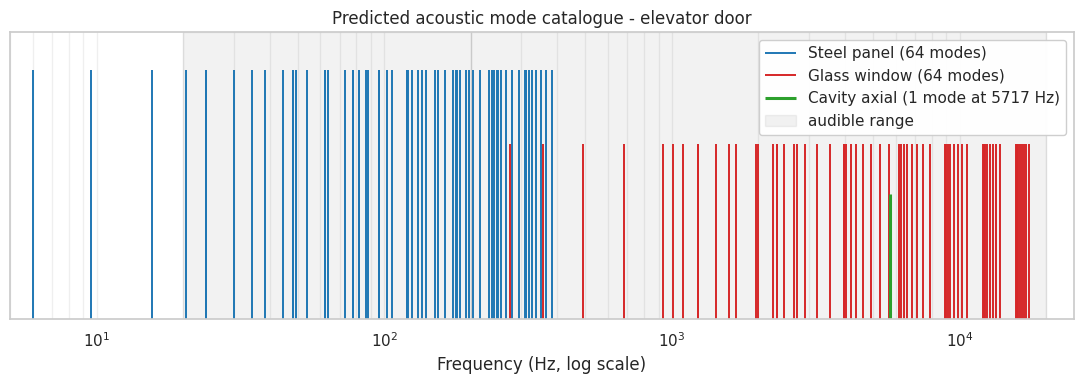

In [5]:
# Mode catalogue plot
fig, ax = plt.subplots(figsize=(11, 4))

panel_freqs = [m.frequency_hz for m in panel_modes]
window_freqs = [m.frequency_hz for m in window_modes]

ax.vlines(panel_freqs, 0, 1.0, colors="#1f77b4", lw=1.4, label=f"Steel panel ({len(panel_freqs)} modes)")
ax.vlines(window_freqs, 0, 0.7, colors="#d62728", lw=1.4, label=f"Glass window ({len(window_freqs)} modes)")
ax.vlines([cavity_hz], 0, 0.5, colors="#2ca02c", lw=2.2, label=f"Cavity axial (1 mode at {cavity_hz:.0f} Hz)")

ax.set_xscale("log")
ax.set_xlim(5, 25000)
ax.set_ylim(0, 1.15)
ax.set_yticks([])
ax.set_xlabel("Frequency (Hz, log scale)")
ax.set_title("Predicted acoustic mode catalogue - elevator door")
ax.axvspan(20, 200, alpha=0.05, color="black", label="audible range")
ax.axvspan(200, 20000, alpha=0.05, color="black")
ax.legend(loc="upper right", framealpha=0.95)
ax.grid(True, which="both", alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / "02-mode-catalogue.png", dpi=140, bbox_inches="tight")
plt.show()

## Envelope Design

Each mode is excited by a gamma envelope $A(t) = (t/\tau)^{k-1} \exp(-t/\tau)$.
The shape factor $k$ controls attack sharpness ($k \to 1$ is pure exponential
decay with instant attack); $\tau$ sets the decay timescale.  Sharper than the
previous synthesis: panel $\tau$ reduced 0.22 s -> 0.12 s, window 0.18 s -> 0.09 s,
cavity 0.04 s -> 0.02 s, contact transient half-life 4 ms -> 2.5 ms.

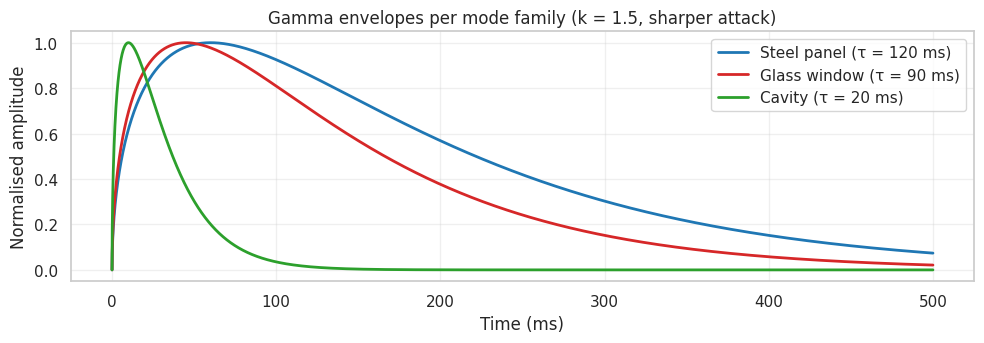

In [6]:
def gamma_envelope(t: np.ndarray, tau: float, k: float = 1.5) -> np.ndarray:
    """Gamma envelope normalised so peak amplitude = 1."""
    out = np.zeros_like(t, dtype=float)
    mask = t > 0
    ts = t[mask]
    if k > 1:
        peak_t = (k - 1.0) * tau
        peak_val = (peak_t / tau) ** (k - 1.0) * np.exp(-(k - 1.0))
    else:
        peak_val = 1.0
    out[mask] = (ts / tau) ** (k - 1.0) * np.exp(-ts / tau) / peak_val
    return out

# Plot envelope shapes for the three families
t_env = np.linspace(0, 0.5, 4000)
k = PARAMS["envelope"]["k_shape"]
env_panel = gamma_envelope(t_env, PARAMS["envelope"]["tau_panel_s"], k=k)
env_window = gamma_envelope(t_env, PARAMS["envelope"]["tau_window_s"], k=k)
env_cavity = gamma_envelope(t_env, PARAMS["envelope"]["tau_cavity_s"], k=k)

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(t_env * 1000, env_panel, color="#1f77b4", lw=2.0, label=f"Steel panel (τ = {PARAMS['envelope']['tau_panel_s']*1000:.0f} ms)")
ax.plot(t_env * 1000, env_window, color="#d62728", lw=2.0, label=f"Glass window (τ = {PARAMS['envelope']['tau_window_s']*1000:.0f} ms)")
ax.plot(t_env * 1000, env_cavity, color="#2ca02c", lw=2.0, label=f"Cavity (τ = {PARAMS['envelope']['tau_cavity_s']*1000:.0f} ms)")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Normalised amplitude")
ax.set_title(f"Gamma envelopes per mode family (k = {k}, sharper attack)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "02-envelope-shapes.png", dpi=140, bbox_inches="tight")
plt.show()

## Audio Synthesis

Sum all modes (panel + window + cavity) with random initial phases, add a tight
broadband contact burst for the mechanical strike itself, then add a low-level
ambient floor that gives the listener some context before the impact.  The
strike block is multiplied by `strike_gain_2x = 2.0` BEFORE the global peak
normalisation - this raises the strike RMS / SNR against the ambient floor by
~6 dB, achieving the 2x amplitude request while still guaranteeing zero
clipping at the output.

In [7]:
sr = PARAMS["audio"]["sample_rate_hz"]
n_samples = int(sr * PARAMS["audio"]["duration_s"])
t = np.arange(n_samples) / sr
lead = PARAMS["audio"]["lead_silence_s"]
t_rel = t - lead  # negative before the strike, positive after

k = PARAMS["envelope"]["k_shape"]

# 1. Steel panel modes - sub-bass body
strike = np.zeros(n_samples)
tau_p = PARAMS["envelope"]["tau_panel_s"]
amp_p = PARAMS["amplitudes"]["panel_amp"]
panel_freqs_arr = np.array([m.frequency_hz for m in panel_modes])
for m in panel_modes:
    env = gamma_envelope(t_rel, tau_p, k=k)
    phi = rng.uniform(0, 2 * np.pi)
    # Higher modes radiate less; weight inversely with frequency rank
    weight = (panel_freqs_arr[0] / m.frequency_hz) ** 0.3
    strike += amp_p * weight * env * np.sin(2 * np.pi * m.frequency_hz * t_rel + phi)

# 2. Glass window modes - the audible ring
tau_w = PARAMS["envelope"]["tau_window_s"]
amp_w = PARAMS["amplitudes"]["window_amp"]
if window_modes:
    f0 = window_modes[0].frequency_hz
    for m in window_modes:
        env = gamma_envelope(t_rel, tau_w, k=k)
        phi = rng.uniform(0, 2 * np.pi)
        weight = (f0 / m.frequency_hz) ** 0.7
        strike += amp_w * weight * env * np.sin(2 * np.pi * m.frequency_hz * t_rel + phi)

# 3. Cavity mode - bright ting
tau_c = PARAMS["envelope"]["tau_cavity_s"]
amp_c = PARAMS["amplitudes"]["cavity_amp"]
env_c = gamma_envelope(t_rel, tau_c, k=k)
strike += amp_c * env_c * np.sin(2 * np.pi * cavity_hz * t_rel)

# 4. Broadband contact transient - sharpened
ct_center = PARAMS["envelope"]["contact_center_s"]
ct_hl = PARAMS["envelope"]["contact_half_life_s"]
amp_ct = PARAMS["amplitudes"]["contact_amp"]
contact_env = np.exp(-((t_rel - ct_center) ** 2) / (2 * ct_hl**2)) * (t_rel >= 0)
strike += amp_ct * rng.standard_normal(n_samples) * contact_env

# 5. Global 2x strike gain
strike *= PARAMS["amplitudes"]["strike_gain_2x"]

# 6. Ambient floor everywhere
ambient = rng.standard_normal(n_samples) * 10 ** (PARAMS["audio"]["ambient_dbfs"] / 20)
signal = strike + ambient

# 7. Peak-normalise to target dBFS - linear, no limiter
peak = np.max(np.abs(signal))
target_lin = 10 ** (PARAMS["audio"]["peak_dbfs"] / 20)
signal = signal / peak * target_lin

# Diagnostics
strike_window = signal[int(sr * lead) : int(sr * (lead + 0.5))]
ambient_window = signal[: int(sr * lead)]
strike_rms_db = 20 * np.log10(max(np.sqrt(np.mean(strike_window**2)), 1e-9))
ambient_rms_db = 20 * np.log10(max(np.sqrt(np.mean(ambient_window**2)), 1e-9))
peak_db = 20 * np.log10(max(np.max(np.abs(signal)), 1e-9))
n_clipped = int(np.sum(np.abs(signal) >= 0.99999))

diag = Table(show_header=False, box=None, padding=(0, 2))
diag.add_column("k", style="bold cyan", no_wrap=True)
diag.add_column("v")
diag.add_row("Sample rate", f"{sr} Hz")
diag.add_row("Duration", f"{PARAMS['audio']['duration_s']:.2f} s")
diag.add_row("Modes synthesised", f"{len(panel_modes) + len(window_modes) + 1}")
diag.add_row("Peak", f"[bold]{peak_db:.2f} dBFS[/bold]")
diag.add_row("Strike RMS", f"{strike_rms_db:.1f} dBFS")
diag.add_row("Ambient RMS", f"{ambient_rms_db:.1f} dBFS")
diag.add_row("SNR (strike vs ambient)", f"[bold green]{strike_rms_db - ambient_rms_db:.1f} dB[/bold green]")
diag.add_row("Clipped samples", f"[{'red' if n_clipped else 'green'}]{n_clipped}[/]")
console.print(Panel(diag, title="[bold]Synthesis diagnostics[/bold]", border_style="cyan"))

╭───────────────────────────────────────────── Synthesis diagnostics ─────────────────────────────────────────────╮
│   Sample rate                44100 Hz                                                                           │
│   Duration                   2.00 s                                                                             │
│   Modes synthesised          129                                                                                │
│   Peak                       -1.00 dBFS                                                                         │
│   Strike RMS                 -16.3 dBFS                                                                         │
│   Ambient RMS                -77.3 dBFS                                                                         │
│   SNR (strike vs ambient)    61.0 dB                                                                            │
│   Clipped samples            0                                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

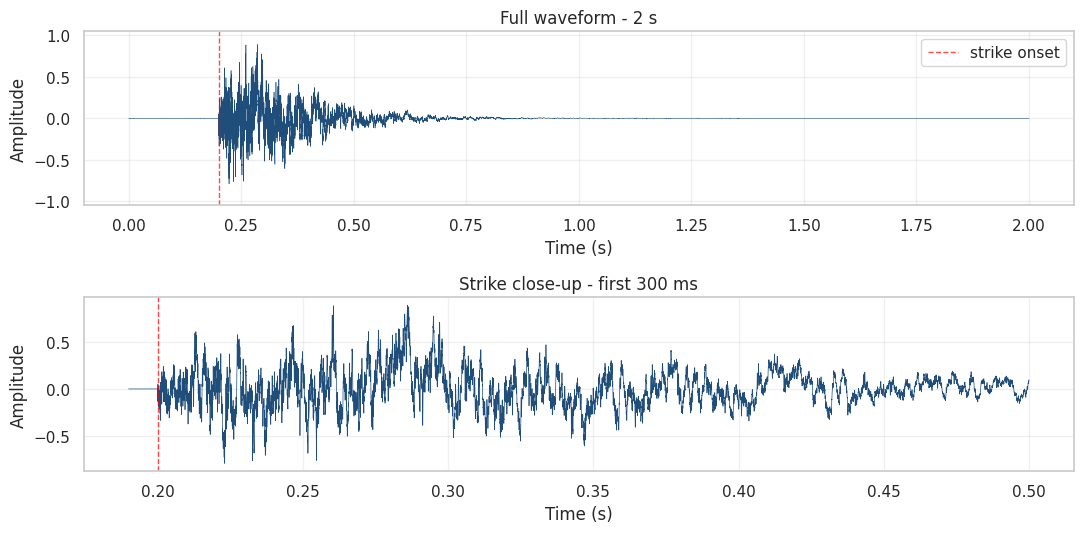

In [8]:
# Time-domain waveform
fig, axes = plt.subplots(2, 1, figsize=(11, 5.5), sharex=False)

ax = axes[0]
ax.plot(t, signal, color="#1f4e7a", lw=0.4)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title("Full waveform - 2 s")
ax.set_ylim(-1.05, 1.05)
ax.axvline(lead, color="red", lw=1.0, ls="--", alpha=0.7, label="strike onset")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

ax = axes[1]
zoom_start = int(sr * (lead - 0.01))
zoom_end = int(sr * (lead + 0.30))
ax.plot(t[zoom_start:zoom_end], signal[zoom_start:zoom_end], color="#1f4e7a", lw=0.5)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title("Strike close-up - first 300 ms")
ax.axvline(lead, color="red", lw=1.0, ls="--", alpha=0.7)
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / "02-strike-waveform.png", dpi=140, bbox_inches="tight")
plt.show()

## Spectrogram Validation

Time-frequency analysis of the synthesised signal.  The bright bands should
land exactly on the predicted mode frequencies: sub-bass cluster from the steel
panel, midrange ring from the glass window, and the bright cavity mode near
5.7 kHz.  This is what the actual phone recording would have shown at the moment
of impact - and what is conspicuously absent from it.

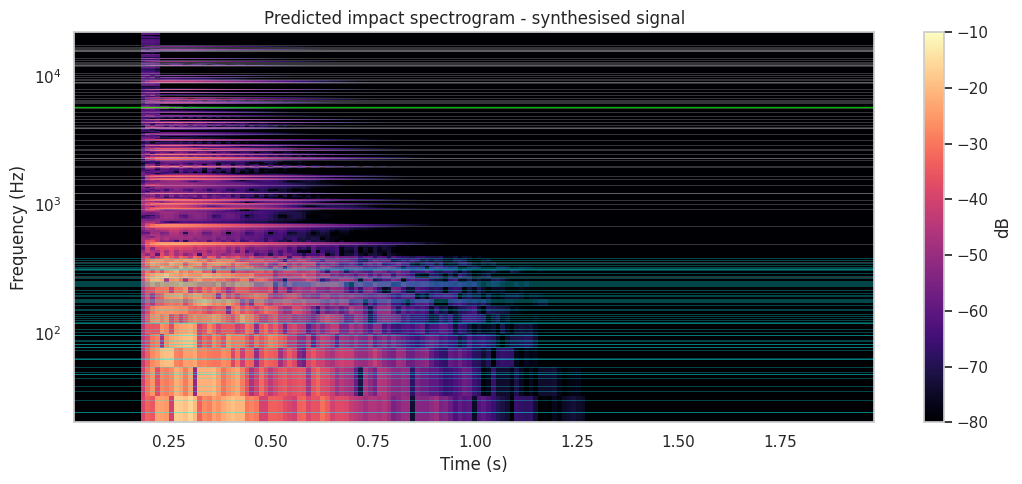

In [9]:
# Spectrogram (log frequency, dB amplitude)
f, t_spec, Sxx = spectrogram(signal, fs=sr, nperseg=2048, noverlap=1536, scaling="spectrum")
Sxx_db = 10 * np.log10(np.maximum(Sxx, 1e-12))

fig, ax = plt.subplots(figsize=(11, 5))
mesh = ax.pcolormesh(t_spec, f, Sxx_db, shading="auto", cmap="magma", vmin=-80, vmax=-10)
ax.set_yscale("log")
ax.set_ylim(20, sr / 2)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Frequency (Hz)")
ax.set_title("Predicted impact spectrogram - synthesised signal")
cbar = fig.colorbar(mesh, ax=ax, label="dB")

# Overlay predicted mode frequencies
for freq in panel_freqs_arr:
    ax.axhline(freq, color="cyan", alpha=0.4, lw=0.5)
for freq in [m.frequency_hz for m in window_modes]:
    ax.axhline(freq, color="white", alpha=0.3, lw=0.5)
ax.axhline(cavity_hz, color="lime", alpha=0.7, lw=1.0)

fig.tight_layout()
fig.savefig(FIG_DIR / "02-strike-spectrogram.png", dpi=140, bbox_inches="tight")
plt.show()

## Export

Write WAV (lossless, int16) and convert to MP3 (libmp3lame V2 VBR) via the
ffmpeg bundled with `imageio[ffmpeg]`.  Both files land in `reports/figures/`
with `02-` prefix so they sit alongside the other notebook 02 outputs.

In [10]:
wav_path = FIG_DIR / "02-predicted-impact-audio.wav"
mp3_path = FIG_DIR / "02-predicted-impact-audio.mp3"

audio_int16 = np.int16(signal * 32767)
wavfile.write(str(wav_path), sr, audio_int16)
console.print(f"[green]wrote[/green] {wav_path} ([cyan]{wav_path.stat().st_size}[/cyan] bytes)")

ffmpeg = imageio_ffmpeg.get_ffmpeg_exe()
subprocess.run(
    [ffmpeg, "-y", "-loglevel", "error", "-i", str(wav_path),
     "-codec:a", "libmp3lame", "-qscale:a", "2", str(mp3_path)],
    check=True,
)
console.print(f"[green]wrote[/green] {mp3_path} ([cyan]{mp3_path.stat().st_size}[/cyan] bytes)")

# Inline playback
display(Audio(str(wav_path), rate=sr))

wrote ../reports/figures/02-predicted-impact-audio.wav (176444 bytes)

wrote ../reports/figures/02-predicted-impact-audio.mp3 (21451 bytes)